# Fase 1: Prapemrosesan (Preprocessing)

## Install library dan unduh dataset

In [ ]:

!pip install wfdb requests PyWavelets

import os, shutil, zipfile, requests
from tqdm.notebook import tqdm
from google.colab import drive

drive.mount('/content/drive')
gdrive_folder = "/content/drive/MyDrive/HF_Detection"
os.makedirs(gdrive_folder, exist_ok=True)

dataset_url = "https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"
zip_filename = "ptb_xl_dataset.zip"
gdrive_path = os.path.join(gdrive_folder, zip_filename)

# --- Cek ukuran asli di server ---
head = requests.head(dataset_url, allow_redirects=True)
total_size = int(head.headers.get('content-length', 0))

# --- Download dengan resume ---
if os.path.exists(gdrive_path) and os.path.getsize(gdrive_path) >= total_size:
    print(f"✓ File sudah lengkap di Drive ({os.path.getsize(gdrive_path)/1e9:.2f} GB)")
else:
    resume_byte = os.path.getsize(gdrive_path) if os.path.exists(gdrive_path) else 0
    headers = {"Range": f"bytes={resume_byte}-"} if resume_byte else {}

    print(f"Downloading... melanjutkan dari {resume_byte/1e6:.1f} MB" if resume_byte else "Downloading dari awal...")

    with requests.get(dataset_url, headers=headers, stream=True) as r:
        r.raise_for_status()
        mode = 'ab' if resume_byte else 'wb'
        with open(gdrive_path, mode) as f, tqdm(
            total=total_size, initial=resume_byte,
            unit='B', unit_scale=True, desc=zip_filename
        ) as pbar:
            for chunk in r.iter_content(chunk_size=1024*1024): # 1MB
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

# Copy ke working dir
print("Menyalin ke direktori kerja...")
shutil.copy2(gdrive_path, zip_filename)

print("Extracting...")
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(".")
print("Selesai!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 128.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
Mounted at /content/drive
✓ File sudah lengkap di Drive (1.84 GB)
Menyalin ke direktori kerja...
Extracting...
Selesai!


## Memuat File Metadata dan Mapping Diagnosis

In [ ]:
import pandas as pd
import ast

base_directory = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

metadata_df = pd.read_csv(base_directory + "ptbxl_database.csv", index_col='ecg_id')

metadata_df.scp_codes = metadata_df.scp_codes.apply(lambda x: ast.literal_eval(x))
print("Metadata successfully loaded. Total records:", len(metadata_df))

Metadata successfully loaded. Total records: 21799


## Memeriksa dan Menangani Nilai yang Hilang (Missing Values)

In [ ]:
print("Missing values before cleaning:")
print(metadata_df[['age', 'sex']].isnull().sum())

metadata_df['age'] = metadata_df['age'].fillna(metadata_df['age'].median())
metadata_df['sex'] = metadata_df['sex'].fillna(metadata_df['sex'].mode()[0])

print("\nMissing values after cleaning:")
print(metadata_df[['age', 'sex']].isnull().sum())

Missing values before cleaning:
age    0
sex    0
dtype: int64

Missing values after cleaning:
age    0
sex    0
dtype: int64


## Melakukan Pemetaan Label (Heart Failure Target Mapping)

In [ ]:
def map_heart_failure(scp_dictionary):
  heart_failure_indicators = ['IMI', 'AMI', 'ALMI', 'ILMI', 'LMI', 'IPLMI', 'PMI']
  for code in scp_dictionary.keys():
    if code in heart_failure_indicators:
      return 1
  return 0

metadata_df['heart_failure_target'] = metadata_df['scp_codes'].apply(map_heart_failure)
print("Target label distribution:")
print(metadata_df['heart_failure_target'].value_counts())

Target label distribution:
heart_failure_target
0    17881
1     3918
Name: count, dtype: int64


## Kode untuk menyeimbangkan jumlah data.

In [ ]:
from sklearn.utils import resample

# Memisahkan kelas mayoritas (0) dan minoritas (1)
df_majority = metadata_df[metadata_df.heart_failure_target == 0]
df_minority = metadata_df[metadata_df.heart_failure_target == 1]

# Lakukan undersampling pada kelas mayoritas agar jumlahnya sama dengan minoritas
df_majority_downsampled = resample(df_majority,
                                 replace=False,
                                 n_samples=len(df_minority),
                                 random_state=42)

# Gabungkan kembali menjadi satu dataframe
metadata_df = pd.concat([df_majority_downsampled, df_minority])

# Acak urutan data kembali
metadata_df = metadata_df.sample(frac=1, random_state=42).reset_index(drop=False)
metadata_df.set_index('ecg_id', inplace=True)

print("Dataset berhasil diseimbangkan!")
print("Distribusi label target yang baru:")
print(metadata_df['heart_failure_target'].value_counts())

Dataset berhasil diseimbangkan!
Distribusi label target yang baru:
heart_failure_target
0    3918
1    3918
Name: count, dtype: int64


## Kode Untuk Data Augmentation

In [ ]:
import numpy as np

def add_gaussian_noise(signal, noise_level=0.01):
    """Menambahkan noise putih ke sinyal."""
    noise = np.random.normal(0, noise_level, signal.shape)
    return signal + noise

def time_shift(signal, shift_limit=50):
    """Menggeser sinyal secara horizontal (time shifting)."""
    shift = np.random.randint(-shift_limit, shift_limit)
    return np.roll(signal, shift, axis=0)

def scaling_signal(signal, scaling_range=(0.9, 1.1)):
    """Mengalikan amplitudo sinyal dengan faktor acak."""
    factor = np.random.uniform(scaling_range[0], scaling_range[1])
    return signal * factor

def augment_ecg_data(X, y, noise_level=0.01, shift_limit=50):
    """
    Melakukan augmentasi pada dataset yang ada untuk menggandakan jumlah data.
    Fungsi ini merujuk pada variabel X_signals dan y_labels yang sudah ada.
    """
    X_aug = []
    y_aug = []

    print("Memulai proses augmentasi data...")
    for i in range(len(X)):
        # Ambil sinyal asli
        original_signal = X[i]
        label = y[i]

        # 1. Tambahkan data asli
        X_aug.append(original_signal)
        y_aug.append(label)

        # 2. Augmentasi: Noise + Scaling
        aug_signal_1 = add_gaussian_noise(original_signal, noise_level)
        aug_signal_1 = scaling_signal(aug_signal_1)
        X_aug.append(aug_signal_1)
        y_aug.append(label)

        # 3. Augmentasi: Time Shift
        aug_signal_2 = time_shift(original_signal, shift_limit)
        X_aug.append(aug_signal_2)
        y_aug.append(label)

    return np.array(X_aug), np.array(y_aug)

# Catatan: Untuk menerapkan ini, Anda dapat menjalankan:
# X_signals, y_labels = augment_ecg_data(X_signals, y_labels)
# print(f"Data setelah augmentasi: {X_signals.shape}")

# Fase 2: Pemetaan (Mapping)

## Memuat Sinyal Gelombang EKG (Waveform Loading)

In [ ]:
import numpy as np
import wfdb

def load_raw_signals(df, path):
  signals = [wfdb.rdsamp(path + filename)[0] for filename in df.filename_lr]
  return np.array(signals)

print("Loading ECG waveforms, please wait...")
X_signals = load_raw_signals(metadata_df, base_directory)
print("Waveforms successfully loaded! Matrix shape:", X_signals.shape)

Loading ECG waveforms, please wait...
Waveforms successfully loaded! Matrix shape: (7836, 1000, 12)


## Mengekstrak Label Target (Target Label Extraction)

In [ ]:
y_labels = metadata_df['heart_failure_target'].values

print("Target labels successfully extracted!")
print("Shape of target array (y):", y_labels.shape)

Target labels successfully extracted!
Shape of target array (y): (7836,)


## Membuat fungsi pembantu

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

# Filter all raw ECG signals to remove noise
def apply_bandpass_filter(ecg_data, low_cutoff=0.5, high_cutoff=40.0, sampling_rate=100.0, filter_order=4):
    nyquist_frequency = 0.5 * sampling_rate
    low_bound = low_cutoff / nyquist_frequency
    high_bound = high_cutoff / nyquist_frequency

    b_coefficient, a_coefficient = butter(filter_order, [low_bound, high_bound], btype='band')
    filtered_signals = filtfilt(b_coefficient, a_coefficient, ecg_data, axis=1)
    return filtered_signals

# Normalized the filtered signals using Z-score
def normalize_ecg_signals(ecg_data):
    mean_values = np.mean(ecg_data, axis=1, keepdims=True)
    std_values = np.std(ecg_data, axis=1, keepdims=True)

    normalized_data = (ecg_data - mean_values) / (std_values + 1e-8)
    return normalized_data

#Fungsi CWT
!pip install PyWavelets

import pywt
from tqdm.notebook import tqdm

# Indeks lead PTB-XL (standar 12-lead): I=0, II=1, III=2, aVR=3, ...
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_INDEX = {'I': 0, 'II': 1, 'III': 2, 'aVR': 3, 'aVL': 4, 'aVF': 5,
              'V1': 6, 'V2': 7, 'V3': 8, 'V4': 9, 'V5': 10, 'V6': 11}


def build_cwt_scales(
    wavelet='cmor1.5-1.0',
    sampling_rate=100.0,
    freq_min=0.5,
    freq_max=40.0,
    n_scales=32,
):
    """
    Buat skala CWT yang memetakan ke rentang frekuensi EKG (0.5–40 Hz).
    """
    center_freq = pywt.central_frequency(wavelet)
    # Frekuensi tinggi → skala kecil; frekuensi rendah → skala besar
    target_freqs = np.logspace(np.log10(freq_max), np.log10(freq_min), n_scales)
    scales = center_freq * sampling_rate / target_freqs
    return scales.astype(np.float64)


def apply_cwt_single_lead(signal_1d, scales, wavelet='cmor1.5-1.0', sampling_rate=100.0):
    """
    signal_1d: (1000,)
    return: (n_scales, 1000) — magnitude skalogram
    """
    coef, _ = pywt.cwt(
        signal_1d,
        scales,
        wavelet,
        sampling_period=1.0 / sampling_rate,
    )
    # Ambil magnitude (penting untuk wavelet kompleks seperti cmor)
    return np.abs(coef).astype(np.float32)


def apply_cwt_ecg(
    ecg_data,
    wavelet='cmor1.5-1.0',
    sampling_rate=100.0,
    n_scales=32,
    lead_indices=None,      # None = semua 12 lead; atau [1] untuk lead II saja
    batch_size=256,         # proses per batch untuk hindari OOM
    verbose=True,
):
    """
    ecg_data: (N, 1000, 12) setelah filter + normalisasi
    return:   (N, n_scales, 1000, n_leads)
    """
    n_samples, n_time, n_leads_total = ecg_data.shape

    if lead_indices is None:
        lead_indices = list(range(n_leads_total))
    n_leads = len(lead_indices)

    scales = build_cwt_scales(wavelet, sampling_rate, n_scales=n_scales)
    output = np.zeros((n_samples, n_scales, n_time, n_leads), dtype=np.float32)

    iterator = range(0, n_samples, batch_size)
    if verbose:
        iterator = tqdm(iterator, desc='CWT processing')

    for start in iterator:
        end = min(start + batch_size, n_samples)
        batch = ecg_data[start:end]

        for local_i, sample in enumerate(batch):
            global_i = start + local_i
            for ch, lead_idx in enumerate(lead_indices):
                output[global_i, :, :, ch] = apply_cwt_single_lead(
                    sample[:, lead_idx], scales, wavelet, sampling_rate
                )

    return output, scales


def normalize_cwt_scalograms(cwt_data, per_sample=True):
    """
    Normalisasi skalogram ke [0, 1] per sampel (standar untuk image-like input).
    cwt_data: (N, n_scales, time, n_leads)
    """
    if per_sample:
        # Min-max per sampel, di semua dimensi spasial
        cwt_min = cwt_data.min(axis=(1, 2, 3), keepdims=True)
        cwt_max = cwt_data.max(axis=(1, 2, 3), keepdims=True)
        return (cwt_data - cwt_min) / (cwt_max - cwt_min + 1e-8)
    else:
        cwt_min = cwt_data.min()
        cwt_max = cwt_data.max()
        return (cwt_data - cwt_min) / (cwt_max - cwt_min + 1e-8)

## Membagi Data Menjadi Train, Validation, dan Test (Fold Splitting)

In [ ]:
#8

import gc
import os
import numpy as np
from tqdm.notebook import tqdm

# Memastikan direktori cache ada
os.makedirs('/content/diasys_cache', exist_ok=True)

# --- Tahap 1: Filter + normalisasi, lalu simpan ke memmap ---
# Gunakan data yang sudah dimuat di X_signals (pastikan cell ICmneGarcyTB sudah dijalankan)
X_signals_filtered = apply_bandpass_filter(X_signals)
X_signals_ready = normalize_ecg_signals(X_signals_filtered)

# Simpan sinyal siap pakai ke disk agar RAM lega
X_signals_path = '/content/diasys_cache/X_signals_ready.dat'
n_total_samples = X_signals_ready.shape[0]

X_signals_memmap = np.memmap(X_signals_path, dtype='float32', mode='w+',
                             shape=X_signals_ready.shape)
X_signals_memmap[:] = X_signals_ready
X_signals_memmap.flush()
del X_signals_ready, X_signals_filtered; gc.collect()

# Baca ulang sebagai read-only dengan shape yang dinamis (sesuai jumlah data saat ini)
X_signals_memmap = np.memmap(X_signals_path, dtype='float32', mode='r',
                             shape=(n_total_samples, 1000, 12))

# --- Tahap 2: Split indeks ---
is_train = metadata_df['strat_fold'] <= 8
is_val   = metadata_df['strat_fold'] == 9
is_test  = metadata_df['strat_fold'] == 10

n_train = np.sum(is_train)
n_val   = np.sum(is_val)
n_test  = np.sum(is_test)

# --- Tahap 3: Konfigurasi CWT ---
CWT_CONFIG = {
    'wavelet': 'cmor1.5-1.0',
    'n_scales': 32,
    'lead_indices': [LEAD_INDEX['II']],
    'batch_size': 128,
}

n_scales = CWT_CONFIG['n_scales']
n_time = X_signals_memmap.shape[1]
n_leads = len(CWT_CONFIG['lead_indices'])

# --- Tahap 4: Alokasi memmap di disk ---
X_train_cwt_path = '/content/diasys_cache/X_train_cwt.dat'
X_val_cwt_path   = '/content/diasys_cache/X_val_cwt.dat'
X_test_cwt_path  = '/content/diasys_cache/X_test_cwt.dat'

X_train_cwt = np.memmap(X_train_cwt_path, dtype='float32', mode='w+',
                        shape=(n_train, n_scales, n_time, n_leads))
X_val_cwt   = np.memmap(X_val_cwt_path,   dtype='float32', mode='w+',
                        shape=(n_val,   n_scales, n_time, n_leads))
X_test_cwt  = np.memmap(X_test_cwt_path,  dtype='float32', mode='w+',
                        shape=(n_test,  n_scales, n_time, n_leads))

# --- Tahap 5: Proses CWT per-batch kecil ---
def process_cwt_to_memmap(ecg_subset, memmap_obj, config, process_batch=32):
    n = ecg_subset.shape[0]
    local_scales = None
    for i in tqdm(range(0, n, process_batch), desc='CWT -> disk'):
        end = min(i + process_batch, n)
        batch_signals = ecg_subset[i:end]
        cwt_batch, local_scales = apply_cwt_ecg(batch_signals, **config, verbose=False)
        cwt_batch = normalize_cwt_scalograms(cwt_batch)
        memmap_obj[i:end] = cwt_batch
        del cwt_batch; gc.collect()
    memmap_obj.flush()
    return local_scales

PROCESS_BATCH = 32
print("Processing CWT for TRAIN...")
scales = process_cwt_to_memmap(X_signals_memmap[is_train], X_train_cwt, CWT_CONFIG, PROCESS_BATCH)
print("Processing CWT for VAL...")
_ = process_cwt_to_memmap(X_signals_memmap[is_val], X_val_cwt, CWT_CONFIG, PROCESS_BATCH)
print("Processing CWT for TEST...")
_ = process_cwt_to_memmap(X_signals_memmap[is_test], X_test_cwt, CWT_CONFIG, PROCESS_BATCH)

del X_signals_memmap; gc.collect()

# Label (y_labels harus sesuai dengan metadata_df yang baru)
y_train = y_labels[is_train]
y_val   = y_labels[is_val]
y_test  = y_labels[is_test]

# Re-open as read-only
X_train_cwt = np.memmap(X_train_cwt_path, dtype='float32', mode='r', shape=(n_train, n_scales, n_time, n_leads))
X_val_cwt   = np.memmap(X_val_cwt_path,   dtype='float32', mode='r', shape=(n_val,   n_scales, n_time, n_leads))
X_test_cwt  = np.memmap(X_test_cwt_path,  dtype='float32', mode='r', shape=(n_test,  n_scales, n_time, n_leads))

print(f"\n--- DISK CACHING BERHASIL ---")
print(f"Train shape: {X_train_cwt.shape} | Val shape: {X_val_cwt.shape} | Test shape: {X_test_cwt.shape}")

Processing CWT for TRAIN...


CWT -> disk:   0%|          | 0/197 [00:00<?, ?it/s]

Processing CWT for VAL...


CWT -> disk:   0%|          | 0/24 [00:00<?, ?it/s]

Processing CWT for TEST...


CWT -> disk:   0%|          | 0/25 [00:00<?, ?it/s]


--- DISK CACHING BERHASIL ---
Train shape: (6291, 32, 1000, 1) | Val shape: (752, 32, 1000, 1) | Test shape: (793, 32, 1000, 1)


### Augmentasi Data Pelatihan untuk Peningkatan Kinerja Model

Untuk meningkatkan performa model, terutama F1-Score dan metrik evaluasi lainnya, kita akan menerapkan **augmentasi data** pada set pelatihan. Augmentasi data membantu model untuk generalisasi lebih baik dengan mengeksposnya pada variasi data yang lebih luas, sehingga mengurangi *overfitting* dan meningkatkan akurasi.

Langkah-langkahnya adalah sebagai berikut:
1.  Ekstraksi sinyal EKG mentah dari `X_signals` untuk set pelatihan (`is_train`).
2.  Menerapkan filter *bandpass* dan normalisasi pada sinyal ini.
3.  Menggunakan fungsi `augment_ecg_data` untuk menghasilkan data pelatihan yang telah diaugmentasi.
4.  Menerapkan transformasi CWT pada sinyal yang diaugmentasi dan menyimpannya ke lokasi *memmap* baru di disk.
5.  Data pelatihan (`X_train_cwt` dan `y_train`) yang digunakan untuk *fitting* model akan diperbarui dengan data yang telah diaugmentasi ini.

In [ ]:
# 1. Persiapkan data sinyal mentah dan label untuk set pelatihan
# Gunakan X_signals asli sebelum diubah menjadi memmap
X_train_raw_signals = X_signals[is_train]
y_train_raw_labels = y_labels[is_train]

print(f"Original raw training signals shape: {X_train_raw_signals.shape}")
print(f"Original raw training labels shape: {y_train_raw_labels.shape}")

# 2. Terapkan filter bandpass dan normalisasi pada sinyal pelatihan mentah
print("Applying bandpass filter and normalization to raw training signals...")
X_train_preprocessed = apply_bandpass_filter(X_train_raw_signals)
X_train_preprocessed = normalize_ecg_signals(X_train_preprocessed)

print(f"Preprocessed training signals shape: {X_train_preprocessed.shape}")

Original raw training signals shape: (6291, 1000, 12)
Original raw training labels shape: (6291,)
Applying bandpass filter and normalization to raw training signals...
Preprocessed training signals shape: (6291, 1000, 12)


In [ ]:
# 3. Lakukan augmentasi data pada sinyal pelatihan yang sudah diproses
# X_train_preprocessed: (N, 1000, 12)
# y_train_raw_labels: (N,)

print("Performing data augmentation...")
X_train_augmented_signals, y_train_augmented = augment_ecg_data(
    X_train_preprocessed,
    y_train_raw_labels,
    noise_level=0.01, # Bisa disesuaikan
    shift_limit=50    # Bisa disesuaikan
)

print(f"Augmented training signals shape: {X_train_augmented_signals.shape}")
print(f"Augmented training labels shape: {y_train_augmented.shape}")

# Bersihkan memori
del X_train_raw_signals, y_train_raw_labels, X_train_preprocessed
gc.collect()

Performing data augmentation...
Memulai proses augmentasi data...
Augmented training signals shape: (18873, 1000, 12)
Augmented training labels shape: (18873,)


4585

In [ ]:
# 4. Proses sinyal yang diaugmentasi dengan CWT dan simpan ke memmap baru

# Tentukan path baru untuk augmented CWT data
X_train_cwt_augmented_path = '/content/diasys_cache/X_train_cwt_augmented.dat'
n_train_augmented = X_train_augmented_signals.shape[0]

# Buat memmap baru untuk data CWT augmented
X_train_cwt_augmented = np.memmap(X_train_cwt_augmented_path, dtype='float32', mode='w+',
                                    shape=(n_train_augmented, n_scales, n_time, n_leads))

print("Processing CWT for AUGMENTED TRAIN data...")
# Gunakan kembali fungsi process_cwt_to_memmap
_ = process_cwt_to_memmap(X_train_augmented_signals, X_train_cwt_augmented, CWT_CONFIG, PROCESS_BATCH)

# Ganti X_train_cwt dan y_train dengan data augmented
X_train_cwt = X_train_cwt_augmented
y_train = y_train_augmented

print(f"Updated X_train_cwt shape: {X_train_cwt.shape}")
print(f"Updated y_train shape: {y_train.shape}")

# Bersihkan memori
del X_train_augmented_signals, y_train_augmented, X_train_cwt_augmented
gc.collect()

print("Data pelatihan augmented CWT berhasil dibuat dan diatur!")

Processing CWT for AUGMENTED TRAIN data...


CWT -> disk:   0%|          | 0/590 [00:00<?, ?it/s]

Updated X_train_cwt shape: (18873, 32, 1000, 1)
Updated y_train shape: (18873,)
Data pelatihan augmented CWT berhasil dibuat dan diatur!


# Fase 3: Pemodelan (Modeling)

## Merancang Arsitektur Model 1D-CNN

In [ ]:
# CNN 2D
# 9

import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Shape input dari CWT: (n_scales, time, n_leads)
input_shape = X_train_cwt.shape[1:]  # contoh: (32, 1000, 1) atau (32, 1000, 12)

model = models.Sequential([
    Input(shape=input_shape),

    # Block 1 — ekstraksi fitur frekuensi-waktu
    layers.Conv2D(32, kernel_size=(3, 7), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 4)),   # → (16, 250, C)

    # Block 2
    layers.Conv2D(64, kernel_size=(3, 5), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 4)),   # → (8, 62, C)

    # Block 3 (opsional, untuk dataset besar)
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),   # → (4, 31, C)

    layers.GlobalAveragePooling2D(),          # lebih ringan dari Flatten
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

NameError: name 'X_train_cwt' is not defined

## Mengompilasi Model (Model Compilation)

In [ ]:
from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras import optimizers, losses
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Calculate class weights
calculated_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dictionary = {0: calculated_weights[0], 1: calculated_weights[1]}

# 2. Compile the model (Fix for the error)
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# 3. Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',    # Monitor validation loss
    factor=0.5,            # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement after which learning rate will be reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1
)

# 4. Fit the model with callbacks
history = model.fit(
    X_train_cwt, y_train,
    validation_data=(X_val_cwt, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight_dictionary,
    callbacks=[early_stopping, lr_reducer],
    verbose=1
)
print("Model training with balanced class weights and callbacks is complete!")

# Fase 4: Evaluasi (Evaluation)

## Melakukan Prediksi pada Data Uji (Generating Predictions)

In [ ]:
predicted_probabilities = model.predict(X_test_cwt)

binary_predictions = (predicted_probabilities > 0.5).astype(int)

print("Predictions successfully generated for the test data!")
print("Sample predictions:", binary_predictions[:5].flatten())

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Predictions successfully generated for the test data!
Sample predictions: [0 0 1 1 0]


## Menghitung Metrik Klinis (Calculating Clinical Metrics)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_accuracy = accuracy_score(y_test, binary_predictions)
test_precision = precision_score(y_test, binary_predictions)
test_recall = recall_score(y_test, binary_predictions)
test_f1 = f1_score(y_test, binary_predictions)

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Precision:      {test_precision:.4f}")
print(f"Recall (Sens):  {test_recall:.4f}")
print(f"F1-Score:       {test_f1:.4f}")

Test Accuracy:  0.6873
Precision:      0.6747
Recall (Sens):  0.7125
F1-Score:       0.6931


## Visualisasi Confusion Matrix (Confusion Matrix Visualization)

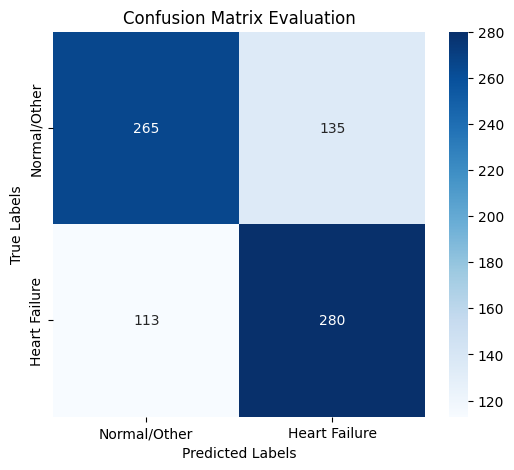

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

evaluation_matrix = confusion_matrix(y_test, binary_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(evaluation_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal/Other', 'Heart Failure'],
            yticklabels=['Normal/Other', 'Heart Failure'])
plt.title('Confusion Matrix Evaluation')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()